In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("Online_Retail.csv")

In [3]:
print("Raws: ",df.shape[0])

Raws:  541909


In [4]:
print("Columns: ",df.shape[1])
df.head()

Columns:  8


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [5]:
print("DataSet Shapes")
df.shape

DataSet Shapes


(541909, 8)

In [6]:
print("\nColumn Names:")
df.columns.tolist()


Column Names:


['InvoiceNo',
 'StockCode',
 'Description',
 'Quantity',
 'InvoiceDate',
 'UnitPrice',
 'CustomerID',
 'Country']

In [7]:
print("\nData Types")
df.dtypes


Data Types


InvoiceNo       object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
UnitPrice      float64
CustomerID     float64
Country         object
dtype: object

In [8]:
print("Missing Values")
df.isnull().sum()

Missing Values


InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [9]:
print("Duplicates Values")
df.duplicated().sum()

Duplicates Values


np.int64(5268)

In [10]:
print("Unique coustomer:", df["CustomerID"].nunique())

Unique coustomer: 4372


In [11]:
print("Unique Product: ", df["StockCode"].nunique())

Unique Product:  4070


In [12]:
print("Unique Country: ", df["Country"].nunique())

Unique Country:  38


In [13]:
print("\nDate Range:")
print("Start Date: ", df["InvoiceDate"].min())
print("End Date: ",df["InvoiceDate"].max())


Date Range:
Start Date:  2010-12-01 08:26:00
End Date:  2011-12-09 12:50:00


In [14]:
print("\nNegative Quantities:", (df["Quantity"] < 0).sum())
print("Zero/Negative Prices:", (df["UnitPrice"] <= 0).sum())


Negative Quantities: 10624
Zero/Negative Prices: 2517


In [15]:
print("Cancelled invoices:",df["InvoiceNo"].astype(str).str.startswith("C").sum())

Cancelled invoices: 9288


In [16]:
print("Unique costomers:", df["CustomerID"].nunique())

Unique costomers: 4372


In [17]:
print("Unique countries:", df["Country"].nunique())

Unique countries: 38


In [18]:
print("Start date:", df["InvoiceDate"].min())

Start date: 2010-12-01 08:26:00


In [19]:
print("End date:", df["InvoiceDate"].max())

End date: 2011-12-09 12:50:00


DATA CLEANING

In [20]:
df_clean = df.copy()
print("Original shape:", df.shape)
print("Working copy shape:",df_clean.shape)

Original shape: (541909, 8)
Working copy shape: (541909, 8)


In [21]:
# Remove duplicates transections
duplicates = df_clean.duplicated().sum()
print("Duplicate rows found:", duplicates)
df_clean = df_clean.drop_duplicates()
print("Shape after removing duplicates:", df_clean.shape)

Duplicate rows found: 5268
Shape after removing duplicates: (536641, 8)


In [22]:
# Convert data types
df_clean["InvoiceNo"] = df_clean["InvoiceNo"].astype(str)
df_clean["StockCode"] = df_clean["StockCode"].astype(str)

df_clean["InvoiceDate"] = pd.to_datetime(df_clean["InvoiceDate"])
print(df_clean.dtypes)

InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID            float64
Country                object
dtype: object


In [23]:
# Handle cancelled transactions
cancelled = df_clean["InvoiceNo"].str.startswith("C").sum()
print("Cancelled transaction rows:", cancelled)

Cancelled transaction rows: 9251


In [24]:
df_clean = df_clean[~df_clean["InvoiceNo"].str.startswith("C")].copy()
print("Shape after removing cancelled transactions:", df_clean.shape)

Shape after removing cancelled transactions: (527390, 8)


In [25]:
df_clean = df_clean[
    ~df_clean["InvoiceNo"].str.startswith("C")
].copy()

print("Shape after removing cancelled transactions:", df_clean.shape)

Shape after removing cancelled transactions: (527390, 8)


In [26]:
negative_qty = (df_clean["Quantity"] < 0).sum()
print("Negative quanntity rows:",negative_qty)
df_clean = df_clean[df_clean["Quantity"]> 0].copy()
print("Shape after quantity cleaning:", df_clean.shape)

Negative quanntity rows: 1336
Shape after quantity cleaning: (526054, 8)


In [27]:
invalid_price = (df_clean["UnitPrice"] <= 0).sum()
print("Invalid price rows:", invalid_price)
df_clean = df_clean[df_clean["UnitPrice"] > 0].copy()
print("invalid price cleaning: ",df_clean.shape)

Invalid price rows: 1176
invalid price cleaning:  (524878, 8)


In [28]:
missing_customer = df_clean["CustomerID"].isna().sum()

print("Missing CustomerID:", missing_customer)

Missing CustomerID: 132186


In [29]:
df_customer = df_clean.dropna(subset=["CustomerID"]).copy()

print("Customer segmentation dataset:", df_customer.shape)

Customer segmentation dataset: (392692, 8)


In [30]:
df_customer["CustomerID"] = df_customer["CustomerID"].astype(int)

print(df_customer["CustomerID"].dtype)

int64


In [31]:
df_customer["Revenue"] = (
    df_customer["Quantity"] * df_customer["UnitPrice"]
)

df_customer.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


In [32]:
df_customer["Year"] = df_customer["InvoiceDate"].dt.year
df_customer["Month"] = df_customer["InvoiceDate"].dt.month
df_customer["Day"] = df_customer["InvoiceDate"].dt.day
df_customer["Hour"] = df_customer["InvoiceDate"].dt.hour
df_customer["Weekday"] = df_customer["InvoiceDate"].dt.day_name()

df_customer.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,Year,Month,Day,Hour,Weekday
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30,2010,12,1,8,Wednesday
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010,12,1,8,Wednesday
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00,2010,12,1,8,Wednesday
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010,12,1,8,Wednesday
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010,12,1,8,Wednesday


In [33]:
print("Final dataset shape:", df_customer.shape)

print("\nMissing values:")
print(df_customer.isnull().sum())

print("\nDuplicate rows:")
print(df_customer.duplicated().sum())

print("\nNegative quantities:")
print((df_customer["Quantity"] < 0).sum())

print("\nInvalid prices:")
print((df_customer["UnitPrice"] <= 0).sum())

print("\nUnique customers:", df_customer["CustomerID"].nunique())

print("Unique products:", df_customer["StockCode"].nunique())

print("Unique countries:", df_customer["Country"].nunique())

Final dataset shape: (392692, 14)

Missing values:
InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
Revenue        0
Year           0
Month          0
Day            0
Hour           0
Weekday        0
dtype: int64

Duplicate rows:
0

Negative quantities:
0

Invalid prices:
0

Unique customers: 4338
Unique products: 3665
Unique countries: 37


In [34]:
total_revenue = df_customer["Revenue"].sum()
total_orders = df_customer["InvoiceNo"].nunique()
total_customers = df_customer["CustomerID"].nunique()
total_products = df_customer["StockCode"].nunique()

print("Total Revenue:", round(total_revenue, 2))
print("Total Orders:", total_orders)
print("Total Customers:", total_customers)
print("Total Products:", total_products)

Total Revenue: 8887208.89
Total Orders: 18532
Total Customers: 4338
Total Products: 3665


In [35]:
order_revenue = df_customer.groupby("InvoiceNo")["Revenue"].sum()

average_order_value = order_revenue.mean()

print("Average Order Value:", round(average_order_value, 2))

Average Order Value: 479.56


In [36]:
monthly_revenue = (
    df_customer
    .groupby(df_customer["InvoiceDate"].dt.to_period("M"))["Revenue"]
    .sum()
    .reset_index()
)

monthly_revenue["InvoiceDate"] = monthly_revenue["InvoiceDate"].astype(str)

monthly_revenue

,InvoiceDate,Revenue
0,2010-12,570422.730
1,2011-01,568101.310
2,2011-02,446084.920
3,2011-03,594081.760
4,2011-04,468374.331
5,2011-05,677355.150
6,2011-06,660046.050
7,2011-07,598962.901
8,2011-08,644051.040
9,2011-09,950690.202


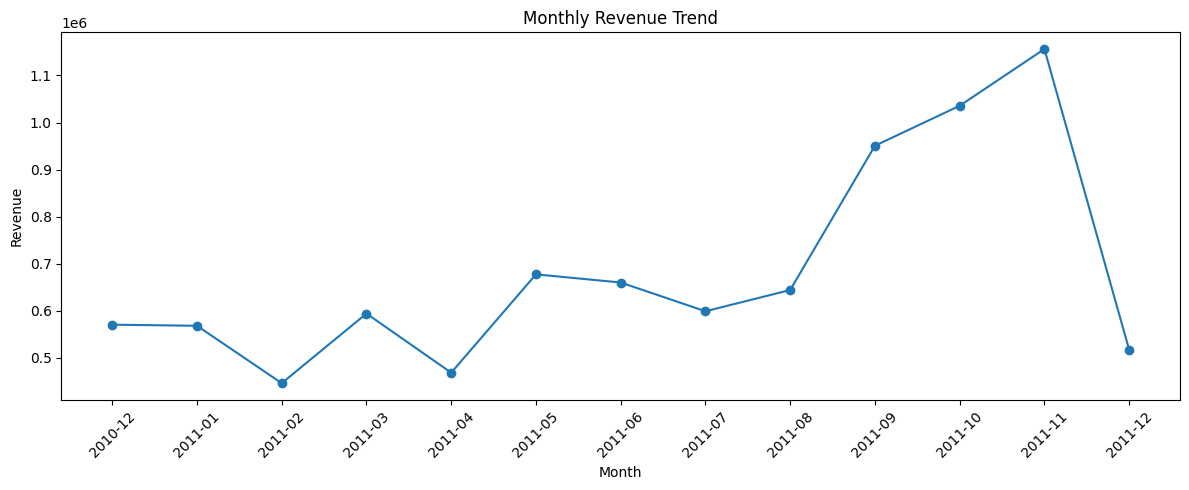

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(
    monthly_revenue["InvoiceDate"],
    monthly_revenue["Revenue"],
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [38]:
top_products = (
    df_customer
    .groupby("Description")["Quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products

Description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        77916
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54319
JUMBO BAG RED RETROSPOT               46078
WHITE HANGING HEART T-LIGHT HOLDER    36706
ASSORTED COLOUR BIRD ORNAMENT         35263
PACK OF 72 RETROSPOT CAKE CASES       33670
POPCORN HOLDER                        30919
RABBIT NIGHT LIGHT                    27153
MINI PAINT SET VINTAGE                26076
Name: Quantity, dtype: int64

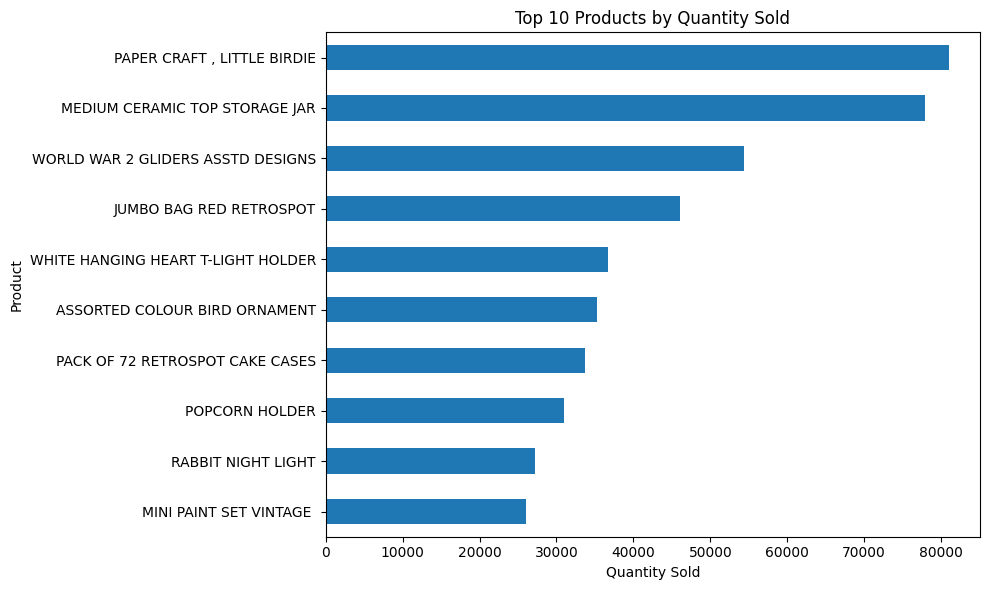

In [39]:
plt.figure(figsize=(10, 6))

top_products.sort_values().plot(kind="barh")

plt.title("Top 10 Products by Quantity Sold")
plt.xlabel("Quantity Sold")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

In [40]:
country_revenue = (
    df_customer
    .groupby("Country")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)

country_revenue.head(10)

Country
United Kingdom    7285024.644
Netherlands        285446.340
EIRE               265262.460
Germany            228678.400
France             208934.310
Australia          138453.810
Spain               61558.560
Switzerland         56443.950
Belgium             41196.340
Sweden              38367.830
Name: Revenue, dtype: float64

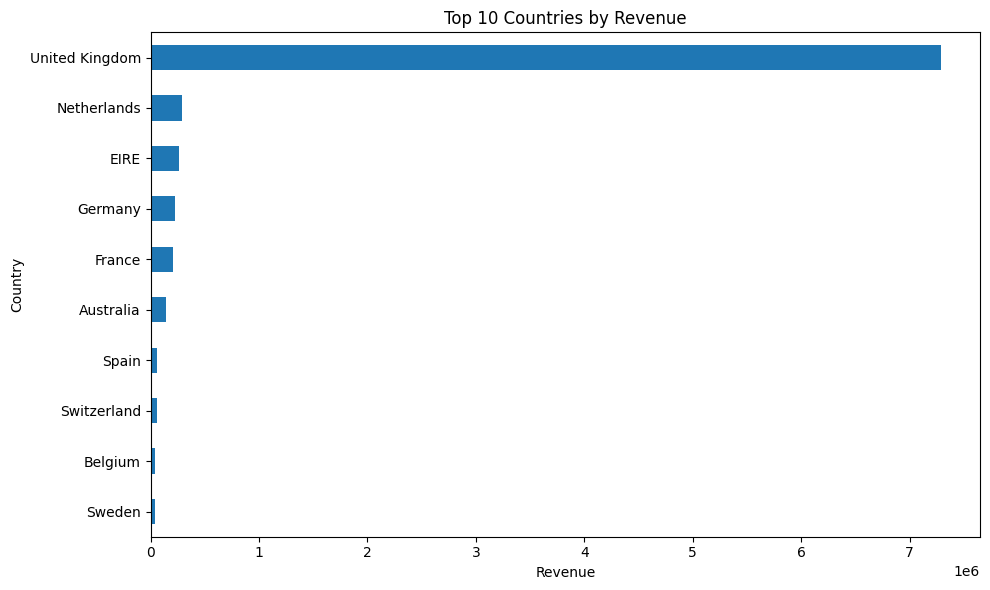

In [41]:
plt.figure(figsize=(10, 6))

country_revenue.head(10).sort_values().plot(kind="barh")

plt.title("Top 10 Countries by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Country")

plt.tight_layout()
plt.show()

In [42]:
weekday_revenue = (
    df_customer
    .groupby("Weekday")["Revenue"]
    .sum()
)

weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

weekday_revenue = weekday_revenue.reindex(weekday_order)

weekday_revenue

Weekday
Monday       1363604.401
Tuesday      1697733.801
Wednesday    1584283.830
Thursday     1973015.730
Friday       1483080.811
Saturday             NaN
Sunday        785490.321
Name: Revenue, dtype: float64

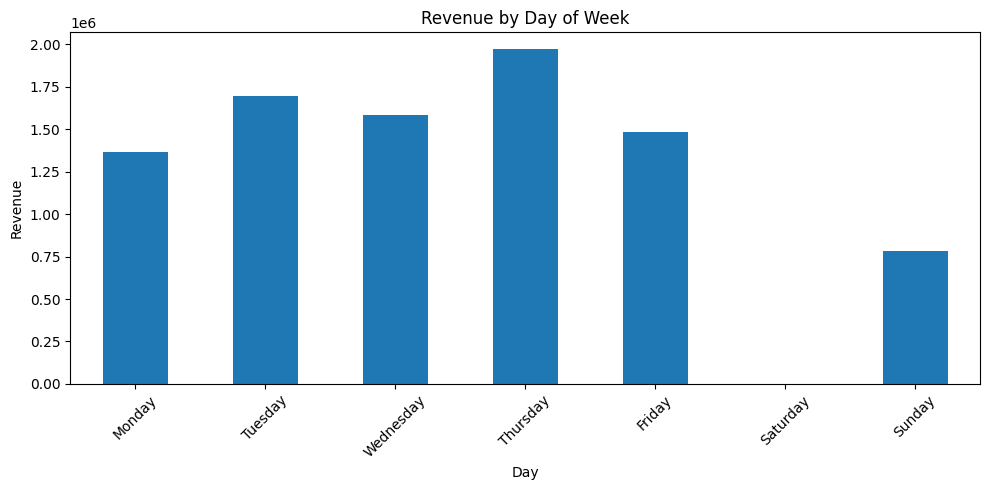

In [43]:
plt.figure(figsize=(10, 5))

weekday_revenue.plot(kind="bar")

plt.title("Revenue by Day of Week")
plt.xlabel("Day")
plt.ylabel("Revenue")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [44]:
hourly_revenue = (
    df_customer
    .groupby("Hour")["Revenue"]
    .sum()
)

hourly_revenue

Hour
6           4.250
7       31059.210
8      281997.790
9      842392.341
10    1259267.591
11    1101177.600
12    1373695.390
13    1168724.200
14     991992.821
15     963559.680
16     467380.560
17     233811.591
18     104744.990
19      48568.400
20      18832.480
Name: Revenue, dtype: float64

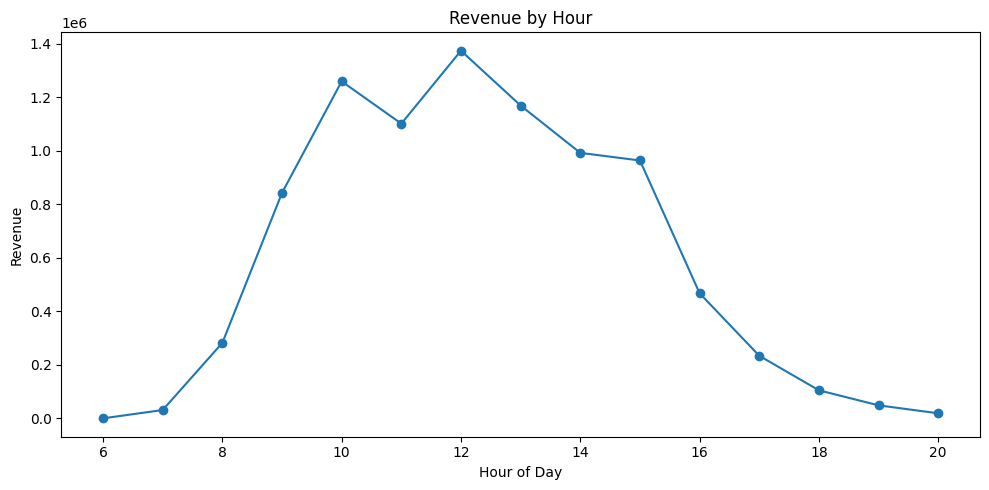

In [45]:
plt.figure(figsize=(10, 5))

hourly_revenue.plot(kind="line", marker="o")

plt.title("Revenue by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Revenue")

plt.tight_layout()
plt.show()

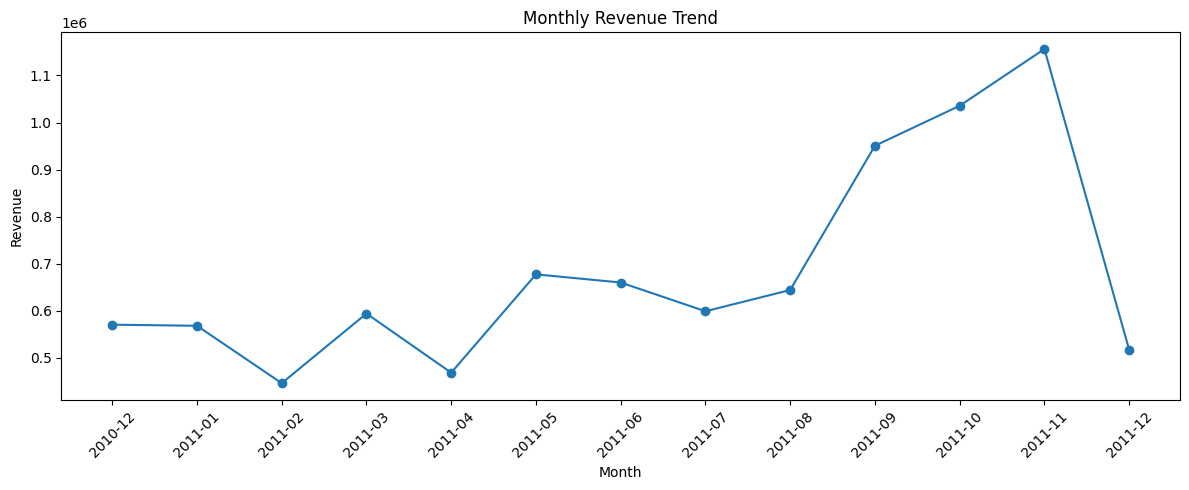

In [46]:
monthly_revenue = (
    df_customer
    .groupby(df_customer["InvoiceDate"].dt.to_period("M"))["Revenue"]
    .sum()
    .reset_index()
)

monthly_revenue["Month"] = monthly_revenue["InvoiceDate"].astype(str)

plt.figure(figsize=(12, 5))
plt.plot(
    monthly_revenue["Month"],
    monthly_revenue["Revenue"],
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

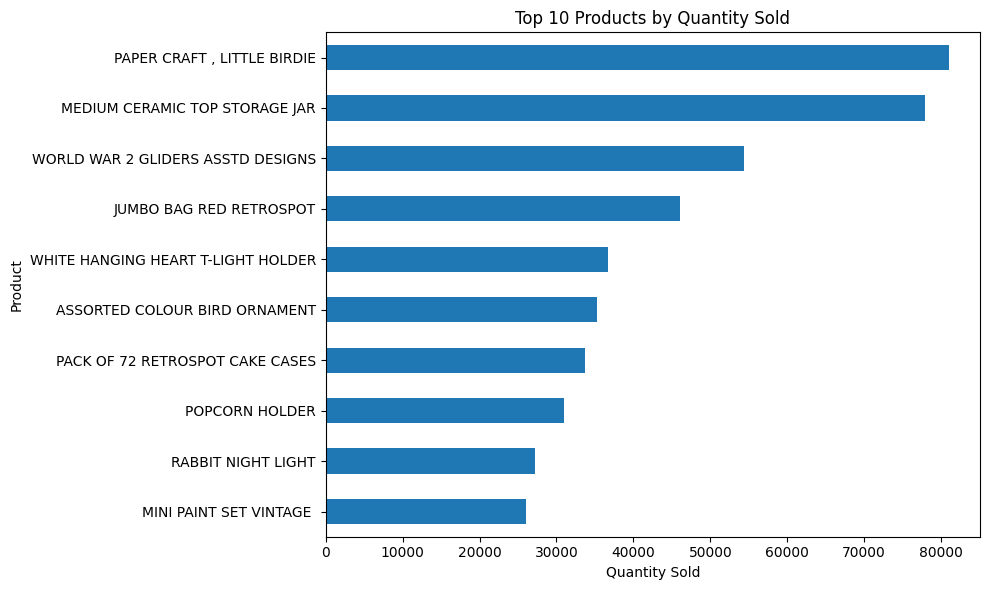

In [47]:
top_products = (
    df_customer
    .groupby("Description")["Quantity"]
    .sum()
    .sort_values(ascending = False)
    .head(10)
)
plt.figure(figsize=(10, 6))
top_products.sort_values().plot(kind = "barh")
plt.title("Top 10 Products by Quantity Sold")
plt.xlabel("Quantity Sold")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

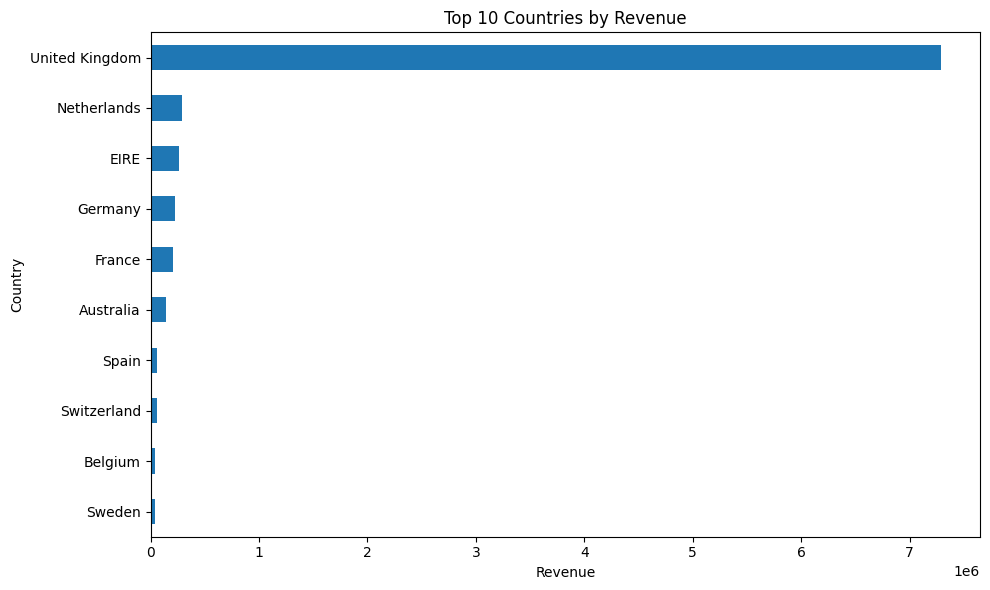

In [48]:
country_revenue = (
    df_customer
    .groupby("Country")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))
country_revenue.sort_values().plot(kind="barh")

plt.title("Top 10 Countries by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

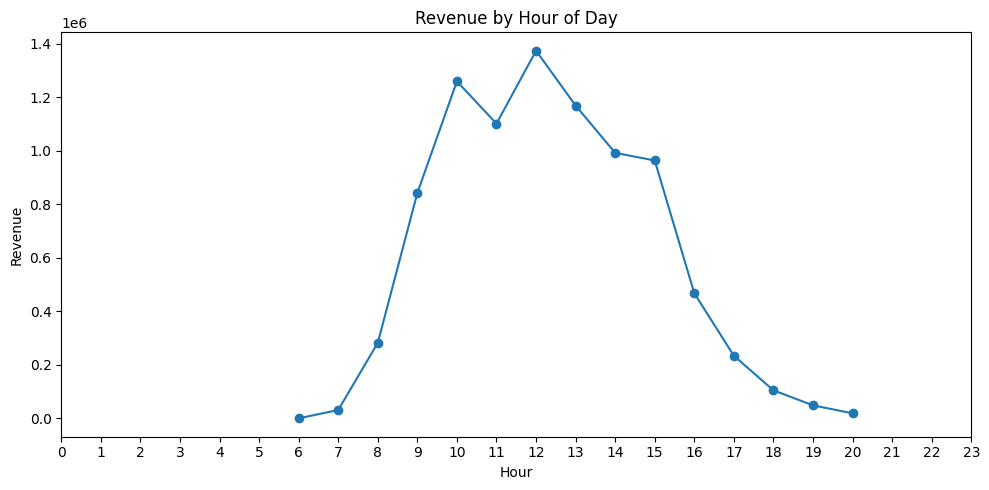

In [49]:
hourly_revenue = (
    df_customer
    .groupby("Hour")["Revenue"]
    .sum()
)

plt.figure(figsize=(10, 5))
hourly_revenue.plot(kind="line", marker="o")

plt.title("Revenue by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Revenue")
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

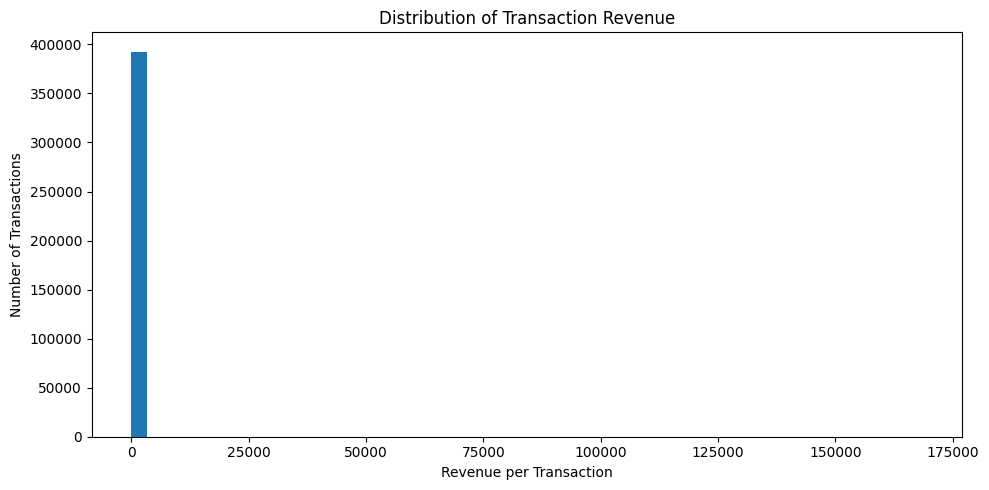

In [50]:
plt.figure(figsize=(10, 5))

plt.hist(
    df_customer["Revenue"],
    bins=50
)

plt.title("Distribution of Transaction Revenue")
plt.xlabel("Revenue per Transaction")
plt.ylabel("Number of Transactions")
plt.tight_layout()
plt.show()

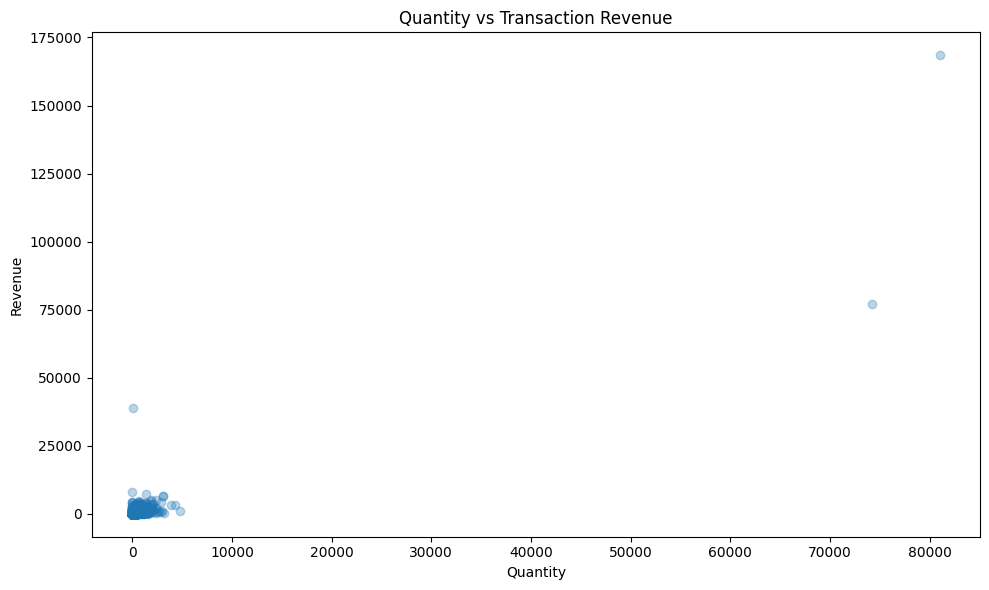

In [51]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df_customer["Quantity"],
    df_customer["Revenue"],
    alpha=0.3
)

plt.title("Quantity vs Transaction Revenue")
plt.xlabel("Quantity")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()

In [52]:
snapshot_date = df_customer["InvoiceDate"].max() + pd.Timedelta(days = 1)
print("Snapshot Date:", snapshot_date)

Snapshot Date: 2011-12-10 12:50:00


In [53]:
rfm = df_customer.groupby("CustomerID").agg({
    "InvoiceDate": lambda x:(snapshot_date - x.max()).days,
    "InvoiceNo":"nunique",
    "Revenue": "sum"
})
rfm.rename(columns={
    "InvoiceDate": "Recency",
    "InvoiceNo":"Frequency",
    "Revenue":"Monetary"
}, inplace = True)
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346,326,1,77183.60
12347,2,7,4310.00
12348,75,4,1797.24
12349,19,1,1757.55
12350,310,1,334.40


In [54]:
print("Number of customers:", rfm.shape[0])

print("\nMissing values:")
print(rfm.isnull().sum())

print("\nRFM statistics:")
print(rfm.describe())

Number of customers: 4338

Missing values:
Recency      0
Frequency    0
Monetary     0
dtype: int64

RFM statistics:
           Recency    Frequency       Monetary
count  4338.000000  4338.000000    4338.000000
mean     92.536422     4.272015    2048.688081
std     100.014169     7.697998    8985.230220
min       1.000000     1.000000       3.750000
25%      18.000000     1.000000     306.482500
50%      51.000000     2.000000     668.570000
75%     142.000000     5.000000    1660.597500
max     374.000000   209.000000  280206.020000


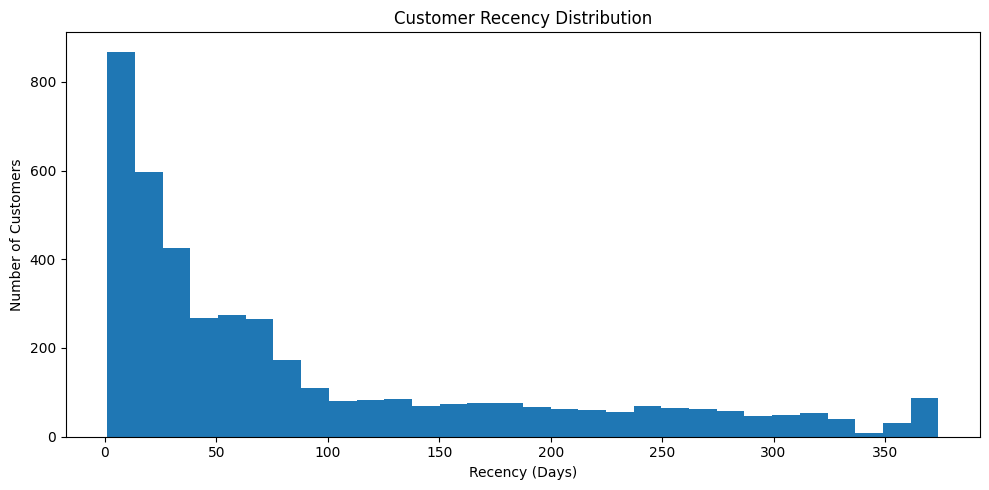

In [55]:
plt.figure(figsize=(10, 5))

plt.hist(rfm["Recency"], bins=30)

plt.title("Customer Recency Distribution")
plt.xlabel("Recency (Days)")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

In [56]:
rfm["R_Score"] = pd.qcut(
    rfm["Recency"],
    5,
    labels=[5, 4, 3, 2, 1],
    duplicates="drop"
)

rfm["F_Score"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5]
)

rfm["M_Score"] = pd.qcut(
    rfm["Monetary"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5]
)

In [57]:
rfm["RFM_Score"] = (
    rfm["R_Score"].astype(int).astype(str) +
    rfm["F_Score"].astype(int).astype(str) +
    rfm["M_Score"].astype(int).astype(str)
)

rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
CustomerID,,,,,,,
12346,326,1,77183.60,1,1,5,115
12347,2,7,4310.00,5,5,5,555
12348,75,4,1797.24,2,4,4,244
12349,19,1,1757.55,4,1,4,414
12350,310,1,334.40,1,1,2,112


In [58]:
rfm_model = rfm[["Recency", "Frequency", "Monetary"]].copy()

rfm_model.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346,326,1,77183.60
12347,2,7,4310.00
12348,75,4,1797.24
12349,19,1,1757.55
12350,310,1,334.40


In [59]:
rfm_log = np.log1p(rfm_model)

rfm_log.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346,5.789960,0.693147,11.253955
12347,1.098612,2.079442,8.368925
12348,4.330733,1.609438,7.494564
12349,2.995732,0.693147,7.472245
12350,5.739793,0.693147,5.815324


In [60]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm_log)

print("Scaled RFM shape:", rfm_scaled.shape)

Scaled RFM shape: (4338, 3)


In [61]:
from sklearn.cluster import KMeans

inertia = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

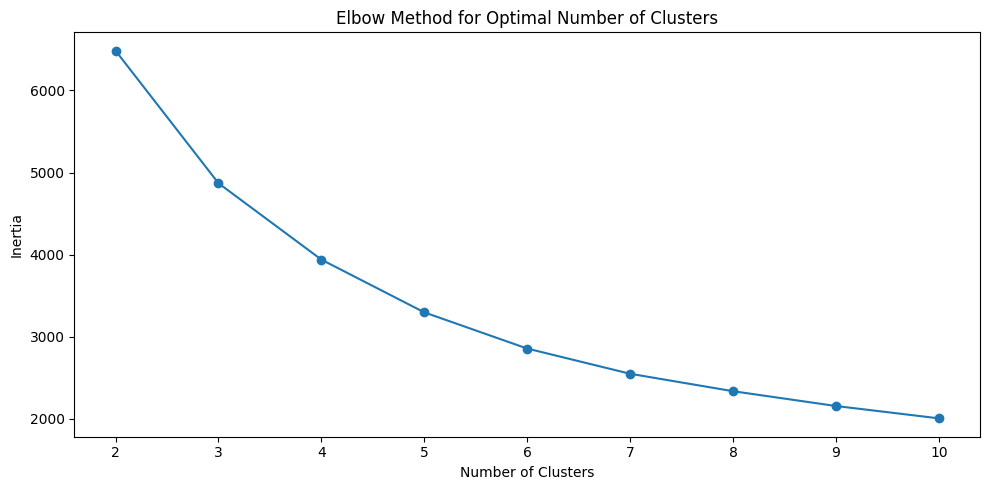

In [62]:
plt.figure(figsize=(10, 5))

plt.plot(
    range(2, 11),
    inertia,
    marker="o"
)

plt.title("Elbow Method for Optimal Number of Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")

plt.tight_layout()
plt.show()

In [63]:
optimal_k = 4

In [64]:
from sklearn.cluster import KMeans
optimal_k = 4

kmeans = KMeans(
    n_clusters = optimal_k,
    random_state = 42,
    n_init = 10
)
rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)
rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Cluster
CustomerID,,,,,,,,
12346,326,1,77183.60,1,1,5,115,3
12347,2,7,4310.00,5,5,5,555,0
12348,75,4,1797.24,2,4,4,244,3
12349,19,1,1757.55,4,1,4,414,2
12350,310,1,334.40,1,1,2,112,1


In [65]:
cluster_counts = rfm["Cluster"].value_counts().sort_index()

print(cluster_counts)

Cluster
0     713
1    1622
2     837
3    1166
Name: count, dtype: int64


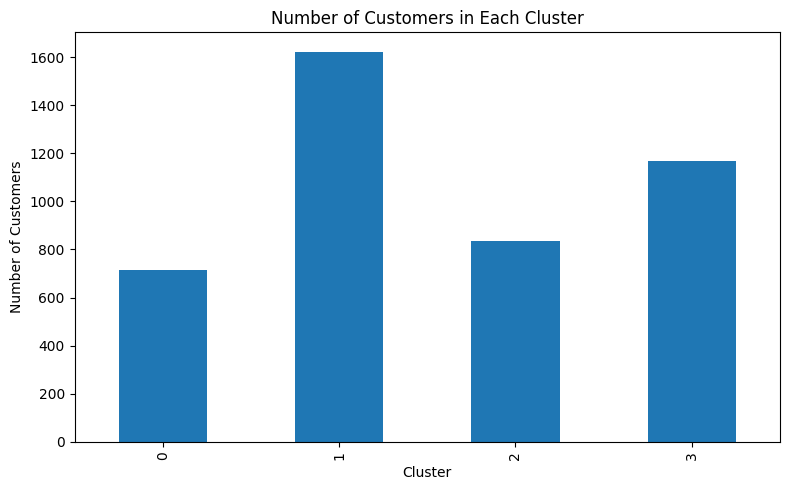

In [66]:
plt.figure(figsize=(8, 5))

cluster_counts.plot(kind="bar")

plt.title("Number of Customers in Each Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

In [67]:
cluster_profile = (
    rfm
    .groupby("Cluster")[["Recency", "Frequency", "Monetary"]]
    .mean()
    .round(2)
)

cluster_profile

,Recency,Frequency,Monetary
Cluster,,,
0,12.17,13.75,8088.02
1,181.51,1.32,341.00
2,17.70,2.19,557.32
3,71.64,4.08,1801.78


In [68]:
profile = cluster_profile.copy()

profile["R_rank"] = profile["Recency"].rank(ascending=True)
profile["F_rank"] = profile["Frequency"].rank(ascending=False)
profile["M_rank"] = profile["Monetary"].rank(ascending=False)

profile["Overall_rank"] = (
    profile["R_rank"] +
    profile["F_rank"] +
    profile["M_rank"]
)

profile.sort_values("Overall_rank")

,Recency,Frequency,Monetary,R_rank,F_rank,M_rank,Overall_rank
Cluster,,,,,,,
0,12.17,13.75,8088.02,1.0,1.0,1.0,3.0
3,71.64,4.08,1801.78,3.0,2.0,2.0,7.0
2,17.70,2.19,557.32,2.0,3.0,3.0,8.0
1,181.51,1.32,341.00,4.0,4.0,4.0,12.0


In [69]:
segment_names = {
    0: "Champions",
    1: "New Customers",
    2: "At Risk",
    3: "Lost Customers"
}

rfm["Segment"] = rfm["Cluster"].map(segment_names)

rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Cluster,Segment
CustomerID,,,,,,,,,
12346,326,1,77183.60,1,1,5,115,3,Lost Customers
12347,2,7,4310.00,5,5,5,555,0,Champions
12348,75,4,1797.24,2,4,4,244,3,Lost Customers
12349,19,1,1757.55,4,1,4,414,2,At Risk
12350,310,1,334.40,1,1,2,112,1,New Customers


In [70]:
segment_counts = rfm["Segment"].value_counts()

print(segment_counts)

Segment
New Customers     1622
Lost Customers    1166
At Risk            837
Champions          713
Name: count, dtype: int64


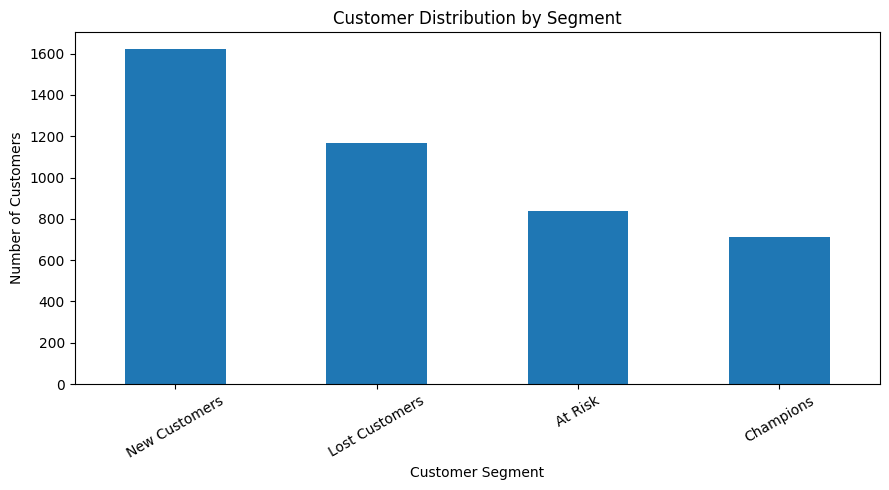

In [71]:
plt.figure(figsize=(9, 5))

segment_counts.plot(kind="bar")

plt.title("Customer Distribution by Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

In [72]:
segment_revenue = (
    rfm
    .groupby("Segment")["Monetary"]
    .sum()
    .sort_values(ascending=False)
)

segment_revenue

Segment
Champions         5766757.070
Lost Customers    2100873.023
New Customers      553099.771
At Risk            466479.030
Name: Monetary, dtype: float64

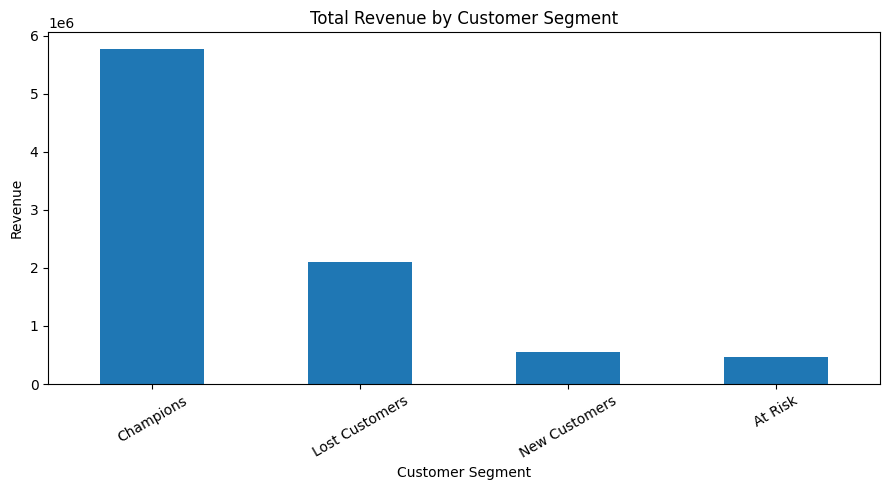

In [73]:
plt.figure(figsize=(9, 5))

segment_revenue.plot(kind="bar")

plt.title("Total Revenue by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Revenue")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

In [74]:
segment_summary = (
    rfm
    .groupby("Segment")[["Recency", "Frequency", "Monetary"]]
    .mean()
    .round(2)
)

segment_summary

,Recency,Frequency,Monetary
Segment,,,
At Risk,17.70,2.19,557.32
Champions,12.17,13.75,8088.02
Lost Customers,71.64,4.08,1801.78
New Customers,181.51,1.32,341.00


In [75]:
from sklearn.metrics import silhouette_score

silhouette = silhouette_score(
    rfm_scaled,
    rfm["Cluster"]
)

print("Silhouette Score:", round(silhouette, 3))

Silhouette Score: 0.338


In [76]:
cluster_profile

,Recency,Frequency,Monetary
Cluster,,,
0,12.17,13.75,8088.02
1,181.51,1.32,341.00
2,17.70,2.19,557.32
3,71.64,4.08,1801.78


In [77]:
final_segment_profile = (
    rfm.groupby("Segment")
    .agg(
        Customers=("Recency", "count"),
        Avg_Recency=("Recency", "mean"),
        Avg_Frequency=("Frequency", "mean"),
        Avg_Monetary=("Monetary", "mean"),
        Total_Revenue=("Monetary", "sum")
    )
    .round(2)
)

final_segment_profile

,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary,Total_Revenue
Segment,,,,,
At Risk,837,17.70,2.19,557.32,466479.03
Champions,713,12.17,13.75,8088.02,5766757.07
Lost Customers,1166,71.64,4.08,1801.78,2100873.02
New Customers,1622,181.51,1.32,341.00,553099.77


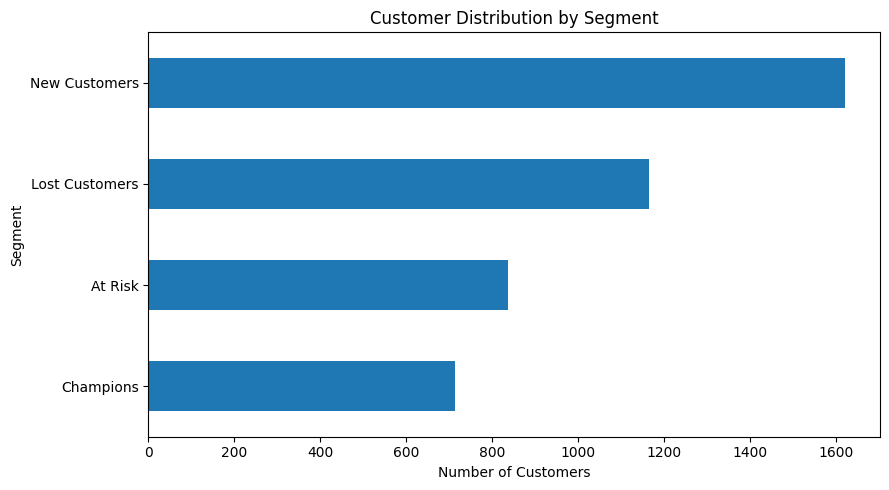

In [78]:
plt.figure(figsize=(9, 5))

final_segment_profile["Customers"].sort_values().plot(kind="barh")

plt.title("Customer Distribution by Segment")
plt.xlabel("Number of Customers")
plt.ylabel("Segment")

plt.tight_layout()
plt.show()

In [79]:
customer_segments = rfm.reset_index()

customer_segments.head()

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Cluster,Segment
0,12346,326,1,77183.60,1,1,5,115,3,Lost Customers
1,12347,2,7,4310.00,5,5,5,555,0,Champions
2,12348,75,4,1797.24,2,4,4,244,3,Lost Customers
3,12349,19,1,1757.55,4,1,4,414,2,At Risk
4,12350,310,1,334.40,1,1,2,112,1,New Customers


In [80]:
customer_segments.to_csv(
    "customer_segments.csv",
    index=False
)

print("Customer segmentation file created successfully.")

Customer segmentation file created successfully.


In [81]:
total_revenue = df_customer["Revenue"].sum()
total_orders = df_customer["InvoiceNo"].nunique()
total_customers = df_customer["CustomerID"].nunique()
total_products = df_customer["StockCode"].nunique()

print("========== E-COMMERCE DASHBOARD ==========")
print(f"Total Revenue      : {total_revenue:,.2f}")
print(f"Total Orders       : {total_orders:,}")
print(f"Total Customers    : {total_customers:,}")
print(f"Total Products     : {total_products:,}")
print(f"Average Order Value: {total_revenue / total_orders:,.2f}")

========== E-COMMERCE DASHBOARD ==========
Total Revenue      : 8,887,208.89
Total Orders       : 18,532
Total Customers    : 4,338
Total Products     : 3,665
Average Order Value: 479.56


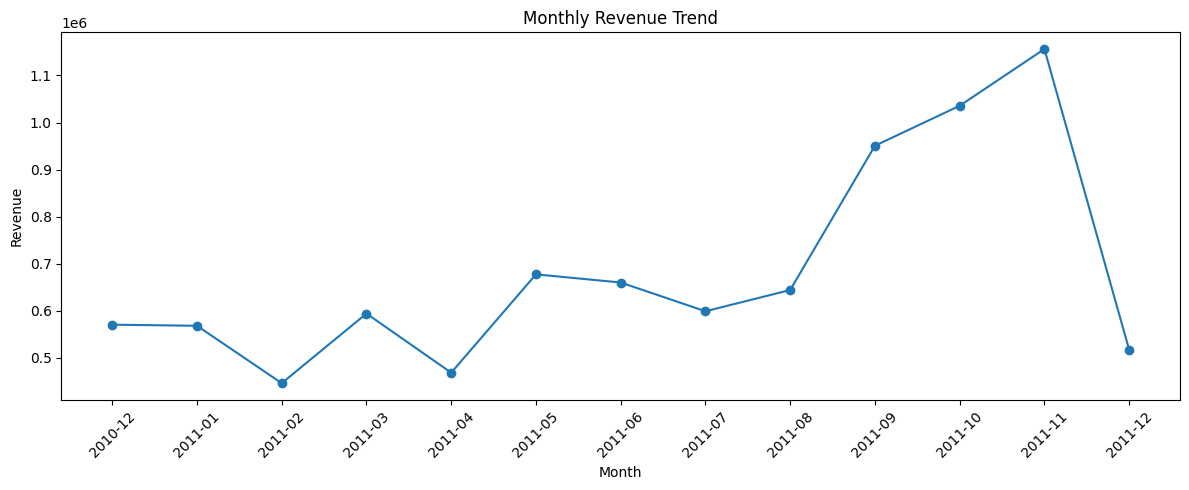

In [82]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_revenue["Month"],
    monthly_revenue["Revenue"],
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

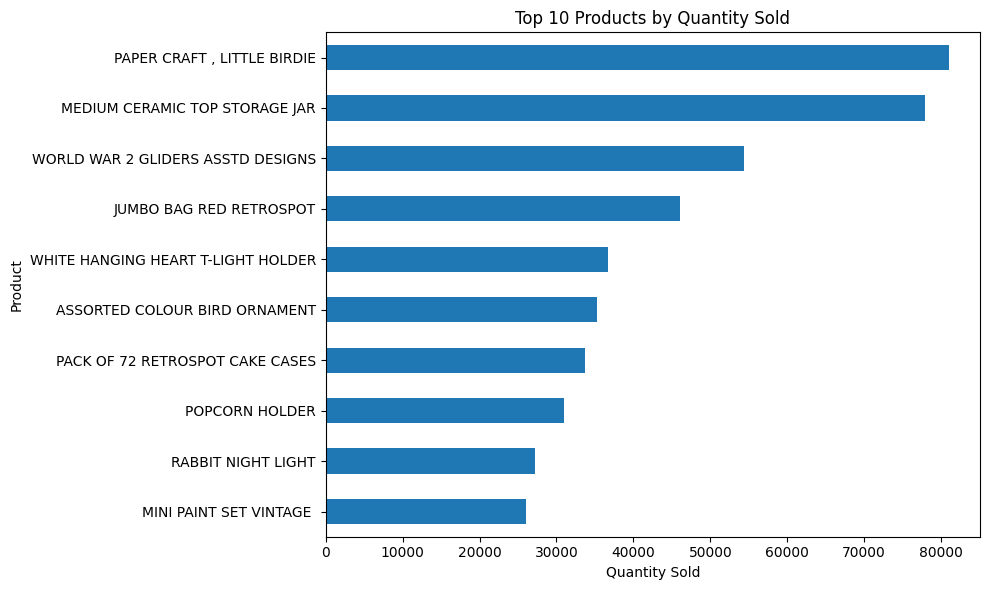

In [83]:
plt.figure(figsize=(10, 6))

top_products.sort_values().plot(kind="barh")

plt.title("Top 10 Products by Quantity Sold")
plt.xlabel("Quantity Sold")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

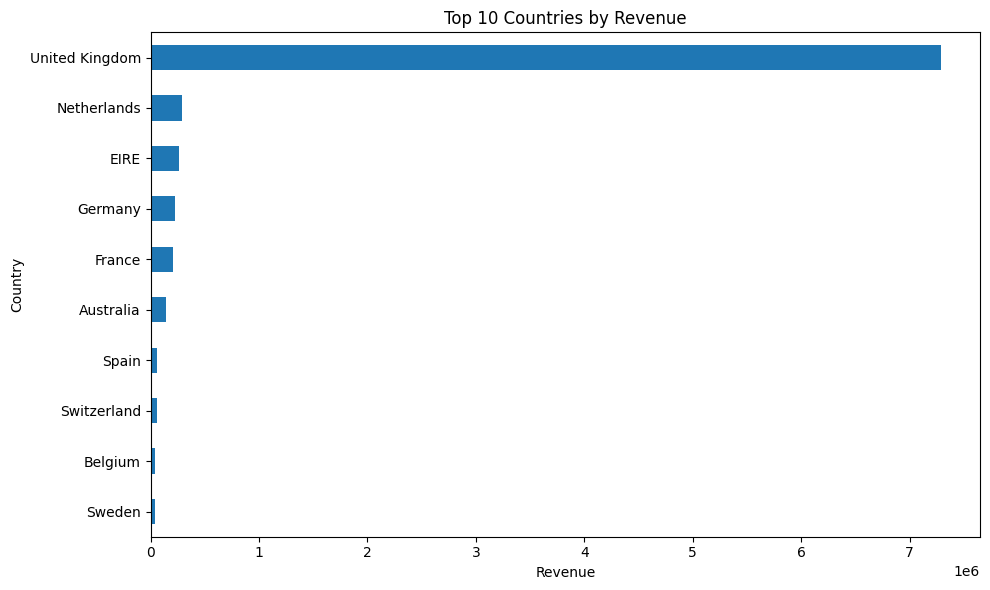

In [84]:
plt.figure(figsize=(10, 6))

country_revenue.sort_values().plot(kind="barh")

plt.title("Top 10 Countries by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Country")

plt.tight_layout()
plt.show()

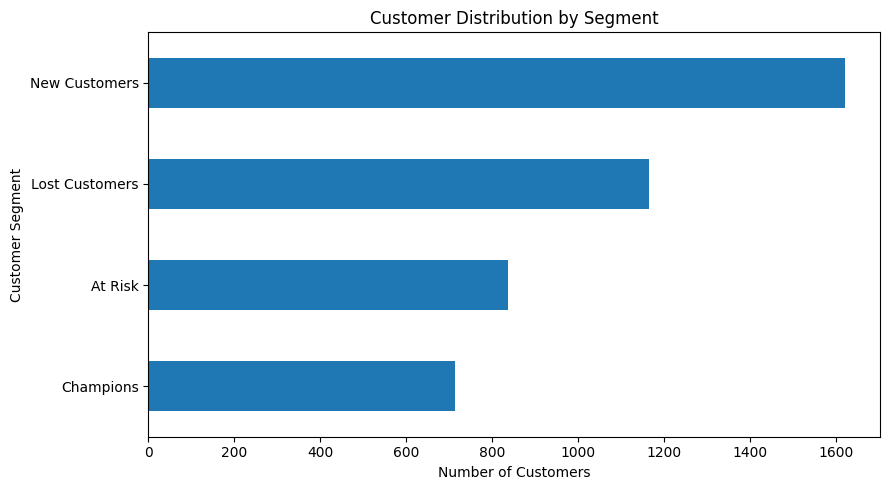

In [85]:
plt.figure(figsize=(9, 5))

final_segment_profile["Customers"].sort_values().plot(kind="barh")

plt.title("Customer Distribution by Segment")
plt.xlabel("Number of Customers")
plt.ylabel("Customer Segment")

plt.tight_layout()
plt.show()

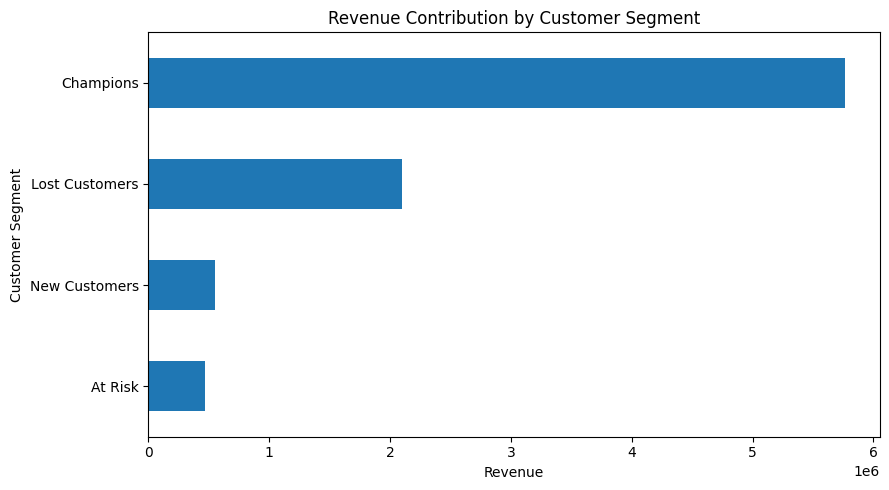

In [86]:
plt.figure(figsize=(9, 5))

final_segment_profile["Total_Revenue"].sort_values().plot(kind="barh")

plt.title("Revenue Contribution by Customer Segment")
plt.xlabel("Revenue")
plt.ylabel("Customer Segment")

plt.tight_layout()
plt.show()

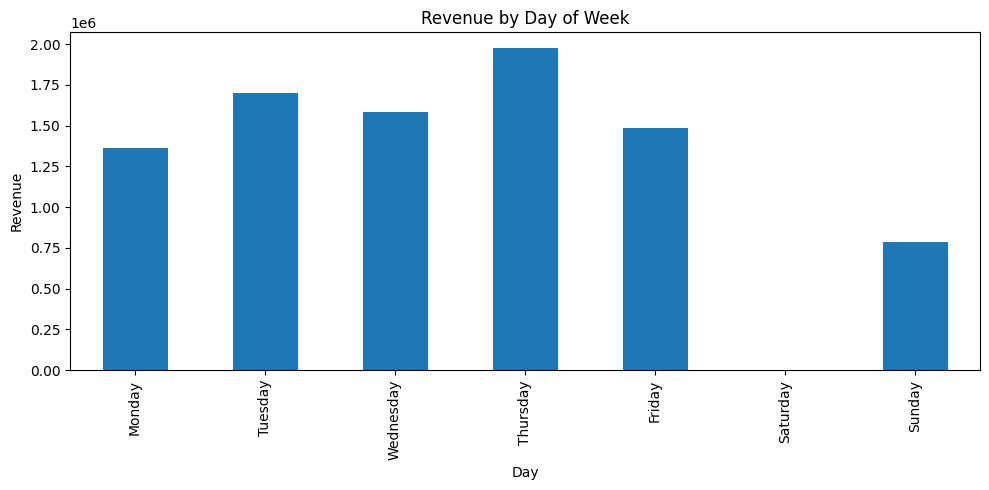

In [87]:
plt.figure(figsize=(10, 5))

weekday_revenue.plot(kind="bar")

plt.title("Revenue by Day of Week")
plt.xlabel("Day")
plt.ylabel("Revenue")

plt.tight_layout()
plt.show()

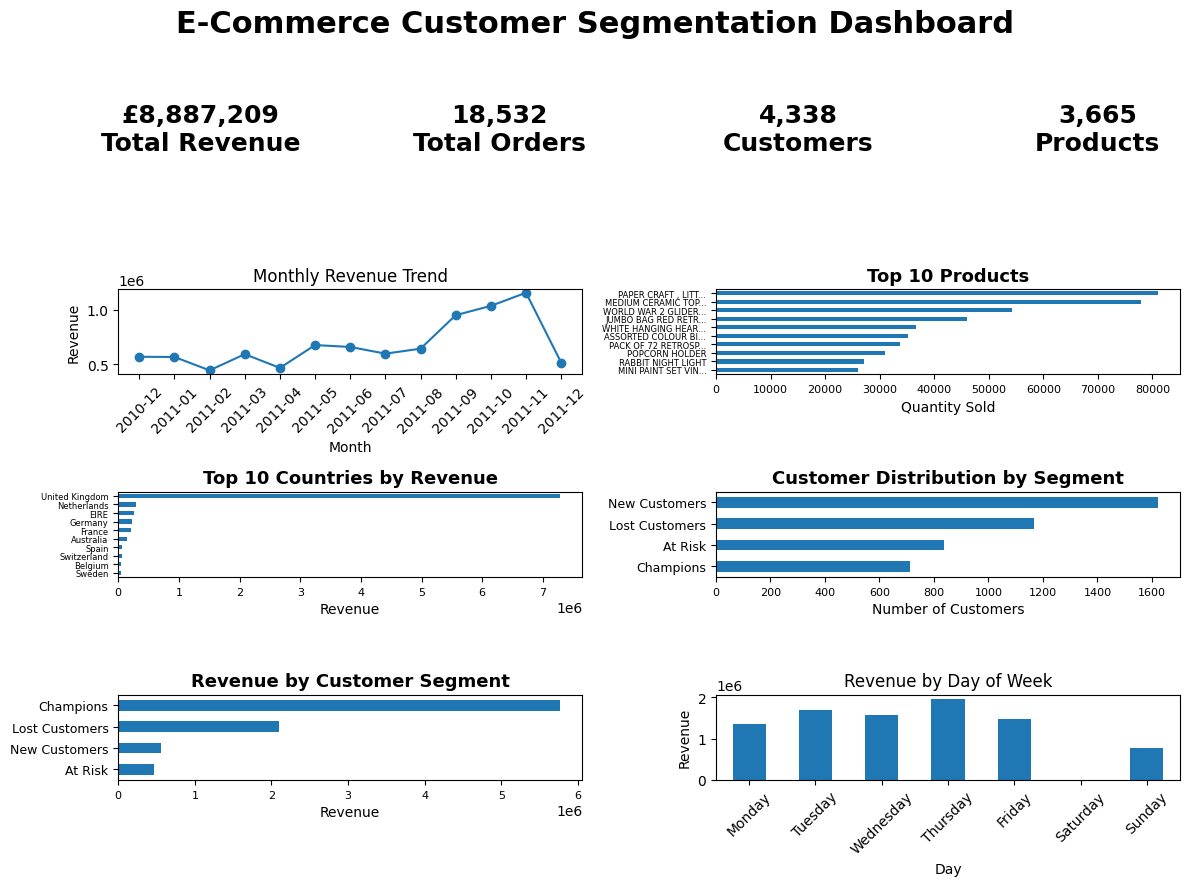

In [88]:
import matplotlib.pyplot as plt

# ==============================
# DASHBOARD DATA
# ==============================

total_revenue = df_customer["Revenue"].sum()
total_orders = df_customer["InvoiceNo"].nunique()
total_customers = df_customer["CustomerID"].nunique()
total_products = df_customer["StockCode"].nunique()

# ==============================
# CREATE DASHBOARD
# ==============================

fig = plt.figure(figsize=(12, 9))

fig.suptitle(
    "E-Commerce Customer Segmentation Dashboard",
    fontsize=22,
    fontweight="bold"
)

# ------------------------------
# KPI 1
# ------------------------------

ax1 = plt.subplot2grid((4, 4), (0, 0))
ax1.axis("off")

ax1.text(
    0.5, 0.5,
    f"£{total_revenue:,.0f}\nTotal Revenue",
    ha="center",
    va="center",
    fontsize=18,
    fontweight="bold"
)

# ------------------------------
# KPI 2
# ------------------------------

ax2 = plt.subplot2grid((4, 4), (0, 1))
ax2.axis("off")

ax2.text(
    0.5, 0.5,
    f"{total_orders:,}\nTotal Orders",
    ha="center",
    va="center",
    fontsize=18,
    fontweight="bold"
)

# ------------------------------
# KPI 3
# ------------------------------

ax3 = plt.subplot2grid((4, 4), (0, 2))
ax3.axis("off")

ax3.text(
    0.5, 0.5,
    f"{total_customers:,}\nCustomers",
    ha="center",
    va="center",
    fontsize=18,
    fontweight="bold"
)

# ------------------------------
# KPI 4
# ------------------------------

ax4 = plt.subplot2grid((4, 4), (0, 3))
ax4.axis("off")

ax4.text(
    0.5, 0.5,
    f"{total_products:,}\nProducts",
    ha="center",
    va="center",
    fontsize=18,
    fontweight="bold"
)

# ==============================
# MONTHLY REVENUE
# ==============================

ax5 = plt.subplot2grid((4, 4), (1, 0), colspan=2)

ax5.plot(
    monthly_revenue["Month"],
    monthly_revenue["Revenue"],
    marker="o"
)

ax5.set_title("Monthly Revenue Trend")
ax5.set_xlabel("Month")
ax5.set_ylabel("Revenue")
ax5.tick_params(axis="x", rotation=45)

# ==============================
# TOP PRODUCTS
# ==============================

ax6 = plt.subplot2grid((4, 4), (1, 2), colspan=2)

top_products_display = top_products.copy()

# Short names
top_products_display.index = [
    str(name)[:18] + "..."
    if len(str(name)) > 18 else str(name)
    for name in top_products_display.index
]

top_products_display.sort_values().plot(
    kind="barh",
    ax=ax6
)

ax6.set_title("Top 10 Products", fontsize=13, fontweight="bold")
ax6.set_xlabel("Quantity Sold")
ax6.set_ylabel("")

ax6.tick_params(axis="y", labelsize=6)
ax6.tick_params(axis="x", labelsize=8)
# ==============================
# TOP COUNTRIES
# ==============================

ax7 = plt.subplot2grid((4, 4), (2, 0), colspan=2)

country_revenue.sort_values().plot(
    kind="barh",
    ax=ax7
)

ax7.set_title(
    "Top 10 Countries by Revenue",
    fontsize=13,
    fontweight="bold"
)

ax7.set_xlabel("Revenue")
ax7.set_ylabel("")

ax7.tick_params(axis="y", labelsize=6)
ax7.tick_params(axis="x", labelsize=8)

# More space for country labels
ax7.margins(y=0.08)
# ==============================
# CUSTOMER SEGMENTS
# ==============================

ax8 = plt.subplot2grid((4, 4), (2, 2), colspan=2)

final_segment_profile["Customers"].sort_values().plot(
    kind="barh",
    ax=ax8
)

ax8.set_title(
    "Customer Distribution by Segment",
    fontsize=13,
    fontweight="bold"
)

ax8.set_xlabel("Number of Customers")
ax8.set_ylabel("")

ax8.tick_params(axis="y", labelsize=9)
ax8.tick_params(axis="x", labelsize=8)

# ==============================
# REVENUE BY SEGMENT
# ==============================

ax9 = plt.subplot2grid((4, 4), (3, 0), colspan=2)

final_segment_profile["Total_Revenue"].sort_values().plot(
    kind="barh",
    ax=ax9
)

ax9.set_title(
    "Revenue by Customer Segment",
    fontsize=13,
    fontweight="bold"
)

ax9.set_xlabel("Revenue")
ax9.set_ylabel("")

ax9.tick_params(axis="y", labelsize=9)
ax9.tick_params(axis="x", labelsize=8)

# ==============================
# WEEKDAY REVENUE
# ==============================

ax10 = plt.subplot2grid((4, 4), (3, 2), colspan=2)

weekday_revenue.plot(
    kind="bar",
    ax=ax10
)

ax10.set_title("Revenue by Day of Week")
ax10.set_xlabel("Day")
ax10.set_ylabel("Revenue")
ax10.tick_params(axis="x", rotation=45)

# ==============================
# FINAL LAYOUT
# ==============================

plt.tight_layout(rect=[0, 0, 1, 0.96])

fig.savefig(
    "ecommerce_customer_segmentation_dashboard.png",
    dpi=150,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

In [89]:
# Fix customer segment names based on actual RFM behavior

segment_mapping = {
    "At Risk": "New Customers",
    "Champions": "Champions",
    "Lost Customers": "Potential Loyalists",
    "New Customers": "Lost Customers"
}

rfm["Segment"] = rfm["Segment"].map(segment_mapping)

# Check the result
rfm["Segment"].value_counts()

Segment
Lost Customers         1622
Potential Loyalists    1166
New Customers           837
Champions               713
Name: count, dtype: int64

In [90]:
final_segment_profile = (
    rfm.groupby("Segment")
    .agg(
        Customers=("Recency", "count"),
        Avg_Recency=("Recency", "mean"),
        Avg_Frequency=("Frequency", "mean"),
        Avg_Monetary=("Monetary", "mean"),
        Total_Revenue=("Monetary", "sum")
    )
    .round(2)
)

final_segment_profile

,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary,Total_Revenue
Segment,,,,,
Champions,713,12.17,13.75,8088.02,5766757.07
Lost Customers,1622,181.51,1.32,341.00,553099.77
New Customers,837,17.70,2.19,557.32,466479.03
Potential Loyalists,1166,71.64,4.08,1801.78,2100873.02


# Business Insights & Recommendations

## Key Findings

### 1. Champions are the highest-value customers
Champions have the highest purchase frequency and monetary value, making them the most valuable customer segment.

**Recommendation:**  
Use loyalty programs, personalized offers, early access to new products, and premium customer service to retain these customers.

### 2. Lost Customers represent a re-engagement opportunity
The Lost Customers segment has relatively high recency values and low purchase frequency, indicating that these customers have become inactive.

**Recommendation:**  
Use win-back campaigns, personalized discounts, email reminders, and product recommendations to encourage repeat purchases.

### 3. New Customers have recently interacted with the business
The New Customers segment has relatively recent purchases but lower frequency and monetary value.

**Recommendation:**  
Focus on onboarding, second-purchase offers, product recommendations, and targeted follow-up campaigns.

### 4. Potential Loyalists have meaningful purchase value
Potential Loyalists show stronger purchasing behavior than low-value customers but have not yet reached the Champions level.

**Recommendation:**  
Encourage repeat purchases through loyalty rewards, bundles, cross-selling, and personalized recommendations.

### 5. The United Kingdom is the dominant market
The United Kingdom contributes the largest share of revenue among the analyzed countries.

**Recommendation:**  
Continue prioritizing the UK market while identifying opportunities for growth in other high-potential countries.

### 6. Revenue shows strong seasonal variation
The monthly revenue analysis shows significant changes throughout the year, with revenue increasing strongly toward the later months of 2011.

**Recommendation:**  
Prepare inventory, promotions, and marketing campaigns ahead of high-demand periods.

### 7. Thursday has the highest revenue
The weekday analysis shows Thursday as the strongest revenue-generating day.

**Recommendation:**  
Consider scheduling major promotions, email campaigns, and targeted offers around high-performing days.

## Overall Business Recommendation

The company should prioritize high-value Champions, re-engage inactive customers, convert new customers into repeat buyers, and use seasonal and weekly sales patterns to optimize marketing and inventory planning.